# 금천구 무더위쉼터 최적 입지 분석

기존 성동구 AED 분석 코드를 **Python/Jupyter용으로 재구성**한 노트북입니다.

분석 흐름은 다음과 같습니다.

1. 금천구 행정동 경계 및 보행 네트워크 구축
2. 고령 유동인구 수요지, 기존 무더위쉼터, 신규 후보지 스냅
3. 네트워크 최단거리 계산
4. 기존 접근성 평가
5. **MCLP (`p=14`)**
6. **p-median (`p=14`)**
7. 두 모형의 커버율·인구가중 평균 접근거리·선정 입지 비교

> **중요:** `COVERAGE_DISTANCE_M`와 고령 유동인구 가중치 컬럼은 데이터센터에서 실제 데이터를 확인한 뒤 설정합니다.


In [10]:
# 필요한 패키지
# 설치가 필요한 경우 아래 주석을 해제해서 실행
# %pip install pandas numpy geopandas shapely pyproj networkx scipy matplotlib pulp openpyxl

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx
import matplotlib.pyplot as plt

from shapely import wkt
from shapely.geometry import Point
from scipy.spatial import cKDTree

import pulp

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)


## 0. 분석 설정

아래 경로와 컬럼명만 실제 파일에 맞게 수정하면 됩니다.

- `P = 14`: 2025년 금천구의 실제 추가 지정 규모를 준용한 시나리오
- `COVERAGE_DISTANCE_M`: MCLP 서비스 기준거리. 최종 분석 전 문헌·정책 근거를 통해 확정
- 수요 가중치: 데이터센터에서 확인한 60대 이상 유동인구 컬럼 사용


In [ ]:
# ============================================================
# 0. 경로 및 분석 설정
# ============================================================

BASE_DIR = Path(r"C:/Users/kwang/OneDrive/바탕 화면/공모전/금천구 더움쉼터 입지 분석 프로젝트/데이터")

NETWORK_PATH = BASE_DIR / "SeoulPedestrianNetwork.csv"
ADM_DONG_PATH = BASE_DIR / "GeumcheonAdministrativeDongBoundary.shp"
EXISTING_PATH = BASE_DIR / "GeumcheonCoolingCenter.csv"
CANDIDATE_PATH = BASE_DIR / "GeumcheonCandidateFacilities.csv"


DEMAND_PATH = BASE_DIR / "Geumcheon_Test_Population_with_Coordinates.csv"  ## 이거는 가서 받아야 하는 데이터이므로 다른 데이터로 연습용으로 한번 실행해보자

ANALYSIS_CRS = 5179
GEOGRAPHIC_CRS = 4326

P = 14
COVERAGE_DISTANCE_M = None

SNAP_CHECK_THRESHOLD_M = 100

CLIP_NETWORK = True
NETWORK_BUFFER_M = 500

EXISTING_LON_COL = "경도"
EXISTING_LAT_COL = "위도"

CANDIDATE_LON_COL = "경도"
CANDIDATE_LAT_COL = "위도"

DEMAND_LON_COL = "경도"  # 이전 : 경도 
DEMAND_LAT_COL = "위도"  # 이전 : 위도

WEIGHT_COL = "population"
WEIGHT_COLS = []

# 예시:
# WEIGHT_COLS = ["남자60대이상유동인구", "여자60대이상유동인구"]


## 1. 보조 함수

In [12]:
def read_vector(path, crs_if_missing=None):
    gdf = gpd.read_file(path)
    if gdf.crs is None and crs_if_missing is not None:
        gdf = gdf.set_crs(crs_if_missing)
    return gdf


def read_point_csv(path, lon_col, lat_col, encoding="utf-8-sig"):
    try:
        df = pd.read_csv(path, encoding=encoding)
    except UnicodeDecodeError:
        df = pd.read_csv(path, encoding="cp949")

    df[lon_col] = pd.to_numeric(df[lon_col], errors="coerce")
    df[lat_col] = pd.to_numeric(df[lat_col], errors="coerce")
    df = df.dropna(subset=[lon_col, lat_col]).copy()

    return gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df[lon_col], df[lat_col]),
        crs=GEOGRAPHIC_CRS
    )


def ensure_points(gdf):
    out = gdf.copy()
    geom_types = set(out.geometry.geom_type.dropna().unique())
    if geom_types and geom_types.issubset({"Polygon", "MultiPolygon"}):
        out["geometry"] = out.representative_point()
    return out


def snap_points_to_nodes(points_gdf, nodes_gdf):
    pts = ensure_points(points_gdf).to_crs(nodes_gdf.crs).copy()

    node_xy = np.column_stack([
        nodes_gdf.geometry.x.to_numpy(),
        nodes_gdf.geometry.y.to_numpy()
    ])
    pt_xy = np.column_stack([
        pts.geometry.x.to_numpy(),
        pts.geometry.y.to_numpy()
    ])

    tree = cKDTree(node_xy)
    dist, idx = tree.query(pt_xy, k=1)

    pts["network_node"] = nodes_gdf.iloc[idx]["node_id"].to_numpy()
    pts["snap_distance_m"] = dist
    return pts


def print_snap_summary(gdf, label, threshold=100):
    s = gdf["snap_distance_m"]
    print(f"\\n[{label}]")
    print(s.describe())
    print(f"{threshold}m 초과: {(s > threshold).sum()}개")


def _endpoint_from_geometry(geom, start=True):
    if geom is None or geom.is_empty:
        return None

    if geom.geom_type == "LineString":
        coords = list(geom.coords)
        return Point(coords[0] if start else coords[-1])

    if geom.geom_type == "MultiLineString":
        parts = list(geom.geoms)
        target = parts[0] if start else parts[-1]
        coords = list(target.coords)
        return Point(coords[0] if start else coords[-1])

    return None


def make_weight(df, weight_col=None, weight_cols=None):
    out = df.copy()

    if weight_col is not None:
        if weight_col not in out.columns:
            raise KeyError(f"가중치 컬럼을 찾을 수 없습니다: {weight_col}")
        out["weight"] = pd.to_numeric(out[weight_col], errors="coerce")

    elif weight_cols:
        missing = [c for c in weight_cols if c not in out.columns]
        if missing:
            raise KeyError(f"가중치 컬럼을 찾을 수 없습니다: {missing}")
        out["weight"] = (
            out[weight_cols]
            .apply(pd.to_numeric, errors="coerce")
            .sum(axis=1, min_count=1)
        )

    else:
        print("수요 데이터 컬럼:")
        print(list(out.columns))
        raise ValueError(
            "WEIGHT_COL 또는 WEIGHT_COLS를 설정한 뒤 다시 실행하세요."
        )

    out["weight"] = out["weight"].fillna(0)
    return out


def weighted_mean(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    mask = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    return np.average(values[mask], weights=weights[mask])


def weighted_coverage(covered, weights):
    covered = np.asarray(covered, dtype=bool)
    weights = np.asarray(weights, dtype=float)
    return weights[covered].sum() / weights.sum()


## 2. 행정동 경계 불러오기

In [13]:
adm_dong = read_vector(ADM_DONG_PATH).to_crs(ANALYSIS_CRS)

print(adm_dong.crs)
print("행정동 수:", len(adm_dong))
display(adm_dong.head())


EPSG:5179
행정동 수: 10


,BASE_DATE,ADM_CD,ADM_NM,geometry
0,20250630,11180510,가산동,"POLYGON ((945134.075 1943182.19, 945138.213 19..."
1,20250630,11180520,독산1동,"POLYGON ((946851.545 1942312.478, 946849.923 1..."
2,20250630,11180530,독산2동,"POLYGON ((947770.689 1941031.612, 947770.422 1..."
3,20250630,11180540,독산3동,"POLYGON ((947748.475 1942473.425, 947756.212 1..."
4,20250630,11180550,독산4동,"POLYGON ((947722.907 1941559.662, 947730.355 1..."


## 3. 서울시 보행 네트워크 구축

기존 AED 분석과 동일한 서울시 자치구별 도보 네트워크 CSV를 사용합니다.

- LINK: 시작노드, 종료노드, 링크 길이
- NODE: 노드 WKT
- 누락된 노드 좌표는 연결 LINK의 시작·끝 좌표로 복원
- 금천구 경계에 buffer를 두어 네트워크를 잘라 계산량을 줄임
- 가장 큰 연결요소만 사용


In [14]:
try:
    network_raw = pd.read_csv(
        NETWORK_PATH,
        encoding="cp949",
        dtype=str,
        low_memory=False
    )
except UnicodeDecodeError:
    network_raw = pd.read_csv(
        NETWORK_PATH,
        encoding="utf-8-sig",
        dtype=str,
        low_memory=False
    )

print("네트워크 원자료:", network_raw.shape)
display(network_raw.head())


네트워크 원자료: (12544, 23)


,노드링크 유형,노드 WKT,노드 ID,노드 유형 코드,링크 WKT,링크 ID,링크 유형 코드,시작노드 ID,종료노드 ID,링크 길이,시군구코드,시군구명,읍면동코드,읍면동명,고가도로,지하철네트워크,교량,터널,육교,횡단보도,"공원,녹지",건물내,수집일자
0,LINK,NaN,0,NaN,LINESTRING(126.88580272643921 37.4711340539878...,197459,1111,173713,173749,17.7820,1154500000,금천구,1154510100,가산동,0,0,0,0,0,0,0,0,2026-09-19 14:38:02.0
1,LINK,NaN,0,NaN,LINESTRING(126.9158142594599 37.45003393578313...,197468,1111,69836,69837,24.0860,1154500000,금천구,1154510300,시흥동,0,0,0,0,0,0,0,0,2026-09-19 14:38:02.0
2,NODE,POINT(126.9040879691176 37.43563395290544),139877,0,NaN,0,NaN,NaN,NaN,NaN,1154500000,금천구,1154510300,시흥동,NaN,NaN,NaN,NaN,0,0,NaN,NaN,2026-09-19 14:40:09.0
3,LINK,NaN,0,NaN,LINESTRING(126.88965843677056 37.4648275701605...,197558,1011,51255,51256,52.0300,1154500000,금천구,1154510200,독산동,0,0,0,0,0,0,0,0,2026-09-19 14:38:02.0
4,LINK,NaN,0,NaN,LINESTRING(126.91004066694336 37.4771357790513...,195829,1111,201637,108291,33.1570,1154500000,금천구,1154510200,독산동,0,0,0,0,0,0,0,0,2026-09-19 14:38:02.0


네트워크 원자료: (12544, 23)


,노드링크 유형,노드 WKT,노드 ID,노드 유형 코드,링크 WKT,링크 ID,링크 유형 코드,시작노드 ID,종료노드 ID,링크 길이,시군구코드,시군구명,읍면동코드,읍면동명,고가도로,지하철네트워크,교량,터널,육교,횡단보도,"공원,녹지",건물내,수집일자
0,LINK,NaN,0,NaN,LINESTRING(126.88580272643921 37.4711340539878...,197459,1111,173713,173749,17.7820,1154500000,금천구,1154510100,가산동,0,0,0,0,0,0,0,0,2026-09-19 14:38:02.0
1,LINK,NaN,0,NaN,LINESTRING(126.9158142594599 37.45003393578313...,197468,1111,69836,69837,24.0860,1154500000,금천구,1154510300,시흥동,0,0,0,0,0,0,0,0,2026-09-19 14:38:02.0
2,NODE,POINT(126.9040879691176 37.43563395290544),139877,0,NaN,0,NaN,NaN,NaN,NaN,1154500000,금천구,1154510300,시흥동,NaN,NaN,NaN,NaN,0,0,NaN,NaN,2026-09-19 14:40:09.0
3,LINK,NaN,0,NaN,LINESTRING(126.88965843677056 37.4648275701605...,197558,1011,51255,51256,52.0300,1154500000,금천구,1154510200,독산동,0,0,0,0,0,0,0,0,2026-09-19 14:38:02.0
4,LINK,NaN,0,NaN,LINESTRING(126.91004066694336 37.4771357790513...,195829,1111,201637,108291,33.1570,1154500000,금천구,1154510200,독산동,0,0,0,0,0,0,0,0,2026-09-19 14:38:02.0


전체 링크 수: 7045
시각화 가능한 링크 수: 7045
좌표계: EPSG:4326


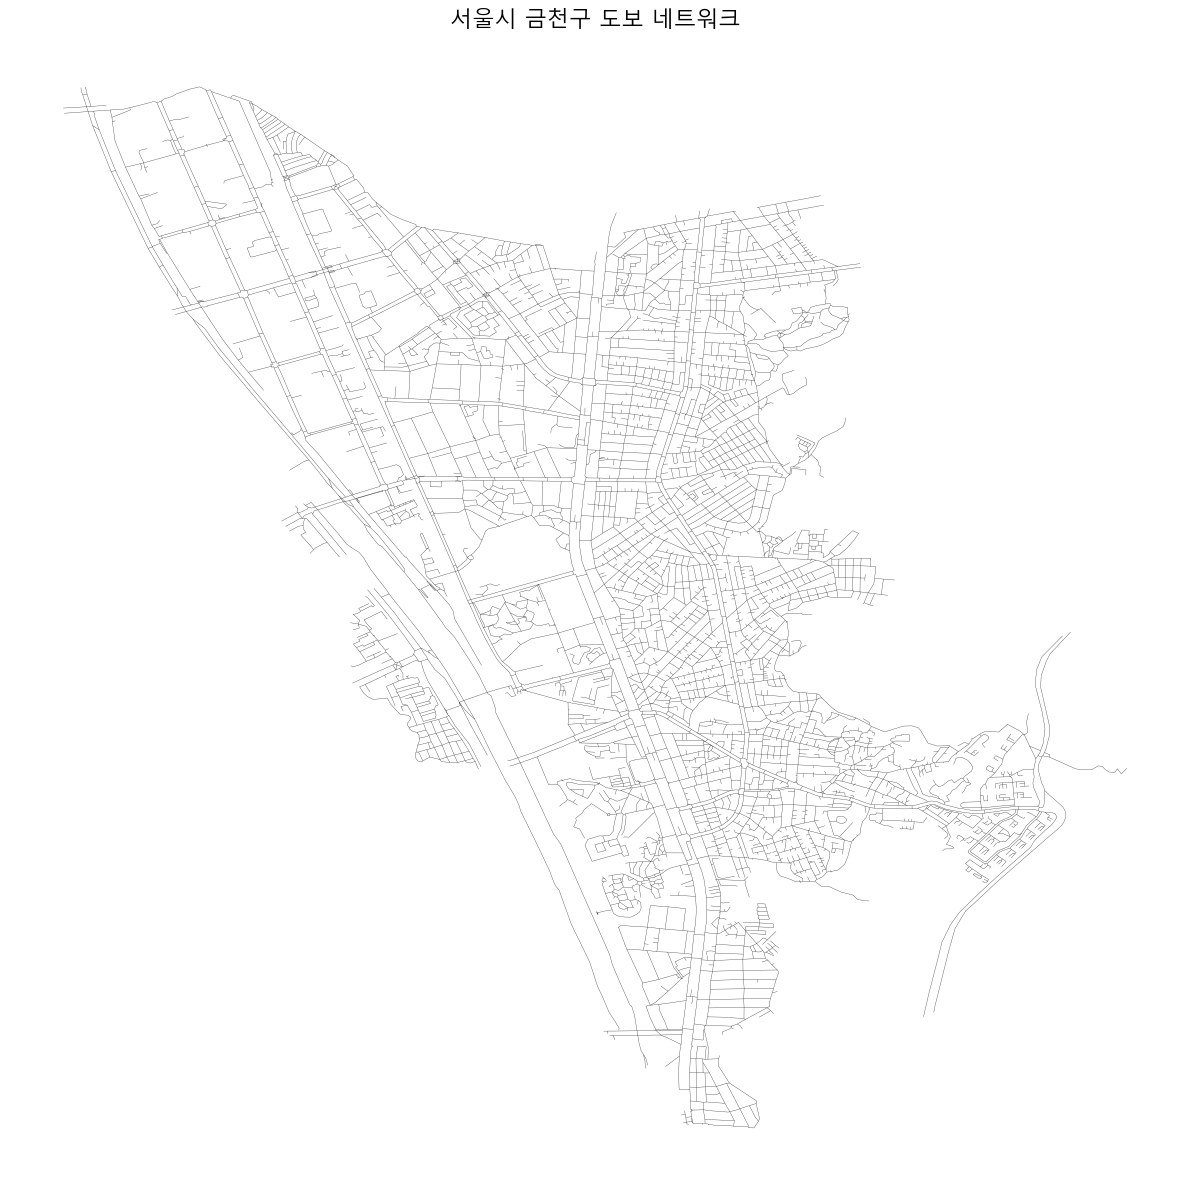

In [15]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely import wkt
from matplotlib import font_manager


# 추가: Windows 한글 글꼴 설정
font_path = r"C:\Windows\Fonts\malgun.ttf"
font_name = font_manager.FontProperties(fname=font_path).get_name()

plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

# 1. 네트워크 데이터 불러오기
try:
    network_raw = pd.read_csv(
        NETWORK_PATH,
        encoding="cp949",
        dtype=str,
        low_memory=False
    )
except UnicodeDecodeError:
    network_raw = pd.read_csv(
        NETWORK_PATH,
        encoding="utf-8-sig",
        dtype=str,
        low_memory=False
    )

print("네트워크 원자료:", network_raw.shape)
display(network_raw.head())


# 2. LINK 데이터만 추출
network_links = network_raw.loc[
    (network_raw["노드링크 유형"] == "LINK")
    & network_raw["링크 WKT"].notna()
    & (network_raw["링크 WKT"].str.strip() != "")
].copy()


# 3. WKT 문자열을 공간 데이터로 변환
def parse_wkt(value):
    try:
        return wkt.loads(value)
    except Exception:
        return None


network_links["geometry"] = network_links["링크 WKT"].map(parse_wkt)
network_links = network_links.dropna(subset=["geometry"])


# 4. GeoDataFrame 생성
network_gdf = gpd.GeoDataFrame(
    network_links,
    geometry="geometry",
    crs="EPSG:4326"
)

print("전체 링크 수:", len(network_links))
print("시각화 가능한 링크 수:", len(network_gdf))
print("좌표계:", network_gdf.crs)


# 5. 도로 네트워크 시각화
fig, ax = plt.subplots(figsize=(12, 12))

network_gdf.plot(
    ax=ax,
    color="black",
    linewidth=0.25,
    alpha=0.8
)

ax.set_title("서울시 금천구 도보 네트워크", fontsize=16)
ax.set_aspect("equal")
ax.axis("off")

plt.tight_layout()
plt.show()

In [16]:
node_rows = network_raw.loc[
    (network_raw["노드링크 유형"] == "NODE")
    & network_raw["노드 WKT"].notna()
    & (network_raw["노드 WKT"] != "")
].copy()

node_rows["geometry"] = node_rows["노드 WKT"].map(wkt.loads)

node_gdf = gpd.GeoDataFrame(
    {
        "node_id": node_rows["노드 ID"].astype(str),
        "node_type": node_rows.get("노드 유형 코드"),
    },
    geometry=node_rows["geometry"],
    crs=GEOGRAPHIC_CRS
).drop_duplicates("node_id")

link_rows = network_raw.loc[
    (network_raw["노드링크 유형"] == "LINK")
    & network_raw["시작노드 ID"].notna()
    & network_raw["종료노드 ID"].notna()
    & network_raw["링크 길이"].notna()
].copy()

link_rows["from"] = link_rows["시작노드 ID"].astype(str)
link_rows["to"] = link_rows["종료노드 ID"].astype(str)
link_rows["length"] = pd.to_numeric(link_rows["링크 길이"], errors="coerce")
link_rows = link_rows.loc[
    np.isfinite(link_rows["length"]) & (link_rows["length"] > 0)
].copy()

graph_node_ids = set(link_rows["from"]) | set(link_rows["to"])
known_ids = set(node_gdf["node_id"])
missing_ids = graph_node_ids - known_ids

if missing_ids:
    recovery = link_rows.loc[
        link_rows["링크 WKT"].notna()
        & (
            link_rows["from"].isin(missing_ids)
            | link_rows["to"].isin(missing_ids)
        )
    ].copy()

    recovered = {}

    for _, row in recovery.iterrows():
        try:
            geom = wkt.loads(row["링크 WKT"])
        except Exception:
            continue

        if row["from"] in missing_ids and row["from"] not in recovered:
            recovered[row["from"]] = _endpoint_from_geometry(geom, start=True)

        if row["to"] in missing_ids and row["to"] not in recovered:
            recovered[row["to"]] = _endpoint_from_geometry(geom, start=False)

    rec_df = pd.DataFrame(
        [(nid, geom) for nid, geom in recovered.items() if geom is not None],
        columns=["node_id", "geometry"]
    )

    if len(rec_df):
        rec_gdf = gpd.GeoDataFrame(
            rec_df,
            geometry="geometry",
            crs=GEOGRAPHIC_CRS
        )
        rec_gdf["node_type"] = None
        node_gdf = pd.concat(
            [node_gdf, rec_gdf[["node_id", "node_type", "geometry"]]],
            ignore_index=True
        )
        node_gdf = gpd.GeoDataFrame(
            node_gdf, geometry="geometry", crs=GEOGRAPHIC_CRS
        ).drop_duplicates("node_id")

node_gdf = node_gdf.to_crs(ANALYSIS_CRS)

remaining_missing = graph_node_ids - set(node_gdf["node_id"])
print("좌표 미복원 네트워크 노드:", len(remaining_missing))


좌표 미복원 네트워크 노드: 0


In [17]:
if CLIP_NETWORK:
    study_geom = adm_dong.geometry.union_all().buffer(NETWORK_BUFFER_M)
    keep_nodes = set(
        node_gdf.loc[node_gdf.geometry.intersects(study_geom), "node_id"]
    )

    link_use = link_rows.loc[
        link_rows["from"].isin(keep_nodes)
        & link_rows["to"].isin(keep_nodes)
    ].copy()
else:
    link_use = link_rows.copy()

G = nx.Graph()

for _, row in link_use.iterrows():
    u = str(row["from"])
    v = str(row["to"])
    length = float(row["length"])

    if G.has_edge(u, v):
        if length < G[u][v]["length"]:
            G[u][v]["length"] = length
    else:
        G.add_edge(u, v, length=length)

largest_cc = max(nx.connected_components(G), key=len)
G = G.subgraph(largest_cc).copy()

node_gdf = node_gdf.loc[
    node_gdf["node_id"].isin(G.nodes)
].drop_duplicates("node_id").copy()

print("그래프 노드:", G.number_of_nodes())
print("그래프 링크:", G.number_of_edges())
print("공간 노드:", len(node_gdf))


그래프 노드: 5504
그래프 링크: 7000
공간 노드: 5504


## 4. 기존 무더위쉼터·후보지·수요지 불러오기

현재 파일 형식에 맞게 경로와 좌표 컬럼명을 수정합니다.


In [18]:
existing = read_point_csv(
    EXISTING_PATH,
    EXISTING_LON_COL,
    EXISTING_LAT_COL
).to_crs(ANALYSIS_CRS)

candidate = read_point_csv(
    CANDIDATE_PATH,
    CANDIDATE_LON_COL,
    CANDIDATE_LAT_COL
).to_crs(ANALYSIS_CRS)

demand = read_point_csv(
    DEMAND_PATH,
    DEMAND_LON_COL,
    DEMAND_LAT_COL
).to_crs(ANALYSIS_CRS)

print("기존 무더위쉼터:", len(existing))
print("원 후보지:", len(candidate))
print("원 수요지:", len(demand))
print("수요지 CRS:", demand.crs)
print("수요지 좌표 범위:", demand.total_bounds)

기존 무더위쉼터: 104
원 후보지: 84
원 수요지: 824637
수요지 CRS: EPSG:5179
수요지 좌표 범위: [ 900050. 1900050.  999950. 1999950.]


### 4-1. 고령 유동인구 가중치 생성

In [19]:
demand = make_weight(
    demand,
    weight_col=WEIGHT_COL,
    weight_cols=WEIGHT_COLS
)

demand = demand.loc[
    np.isfinite(demand["weight"]) & (demand["weight"] > 0)
].copy()

print("양(+)의 가중치를 가진 수요격자:", len(demand))
print("총 고령 유동수요:", demand["weight"].sum())
display(demand.head())


양(+)의 가중치를 가진 수요격자: 185195
총 고령 유동수요: 25219497


,GRID_CD,geometry,population,경도,위도,weight
328,다사744004,POINT (974450 1900450),8,127.212459,37.102349,8
351,다사767004,POINT (976750 1900450),5,127.238343,37.102409,5
391,다사807004,POINT (980750 1900450),5,127.283359,37.102499,5
396,다사812004,POINT (981250 1900450),5,127.288986,37.102510,5
414,다사830004,POINT (983050 1900450),5,127.309243,37.102544,5


## 5. 네트워크 노드에 스냅

In [20]:
demand = snap_points_to_nodes(demand, node_gdf)
existing = snap_points_to_nodes(existing, node_gdf)
candidate = snap_points_to_nodes(candidate, node_gdf)

print_snap_summary(demand, "수요지", SNAP_CHECK_THRESHOLD_M)
print_snap_summary(existing, "기존 무더위쉼터", SNAP_CHECK_THRESHOLD_M)
print_snap_summary(candidate, "후보지", SNAP_CHECK_THRESHOLD_M)


\n[수요지]
count    185195.000000
mean      28551.290489
std       14638.751914
min           0.807626
25%       17420.812429
50%       27796.080222
75%       39492.200104
max       74039.145887
Name: snap_distance_m, dtype: float64
100m 초과: 184394개
\n[기존 무더위쉼터]
count    104.000000
mean      25.452953
std       14.744787
min        6.418104
25%       15.863787
50%       22.083992
75%       32.068284
max       91.026278
Name: snap_distance_m, dtype: float64
100m 초과: 0개
\n[후보지]
count    84.000000
mean     25.998922
std      14.995392
min       6.418104
25%      15.949745
50%      22.050033
75%      32.533239
max      85.259480
Name: snap_distance_m, dtype: float64
100m 초과: 0개


## 6. 분석용 수요지·기존시설·후보지 정리

- 동일 네트워크 노드에 연결된 수요격자는 가중치를 합산
- 동일 네트워크 노드의 후보지는 하나만 남김
- 기존 무더위쉼터와 같은 노드의 후보지는 제거


In [21]:
graph_nodes = set(G.nodes)

existing_clean = existing.loc[
    existing["network_node"].isin(graph_nodes)
].copy()

existing_nodes = existing_clean["network_node"].drop_duplicates().tolist()

candidate_clean = (
    candidate.loc[candidate["network_node"].isin(graph_nodes)]
    .sort_values("snap_distance_m")
    .drop_duplicates("network_node", keep="first")
    .copy()
)

candidate_clean = candidate_clean.loc[
    ~candidate_clean["network_node"].isin(existing_nodes)
].copy()

candidate_clean = candidate_clean.reset_index(drop=True)
candidate_clean["candidate_id"] = [
    f"C{i:03d}" for i in range(1, len(candidate_clean) + 1)
]

demand_model = (
    demand.loc[demand["network_node"].isin(graph_nodes)]
    .groupby("network_node", as_index=False)
    .agg(
        weight=("weight", "sum"),
        n_grid=("weight", "size")
    )
)

demand_model["demand_id"] = [
    f"D{i:04d}" for i in range(1, len(demand_model) + 1)
]

print("기존 쉼터 고유 노드:", len(existing_nodes))
print("최종 후보지:", len(candidate_clean))
print("네트워크 노드 기준 통합 후 수요지:", len(demand_model))
print("총 고령 유동수요:", demand_model["weight"].sum())


기존 쉼터 고유 노드: 100
최종 후보지: 37
네트워크 노드 기준 통합 후 수요지: 841
총 고령 유동수요: 25219497


## 7. 네트워크 최단거리 계산

- 기존 쉼터까지 거리는 `multi_source_dijkstra`로 한 번에 계산
- 후보지까지 거리는 후보지별 Dijkstra를 실행하여 행렬 생성


In [22]:
nearest_existing_dict = nx.multi_source_dijkstra_path_length(
    G,
    sources=existing_nodes,
    weight="length"
)

demand_nodes = demand_model["network_node"].tolist()

nearest_existing_m = np.array([
    nearest_existing_dict.get(n, np.inf)
    for n in demand_nodes
], dtype=float)

demand_model["nearest_existing_m"] = nearest_existing_m

print(demand_model["nearest_existing_m"].describe())
print(
    "기존 쉼터까지 인구가중 평균거리:",
    round(
        weighted_mean(
            demand_model["nearest_existing_m"],
            demand_model["weight"]
        ),
        2
    ),
    "m"
)


count     841.000000
mean      267.641220
std       222.206209
min         0.000000
25%       136.843000
50%       221.606000
75%       344.130000
max      3320.136000
Name: nearest_existing_m, dtype: float64
기존 쉼터까지 인구가중 평균거리: 747.67 m


In [23]:
candidate_nodes = candidate_clean["network_node"].tolist()
demand_index_by_node = defaultdict(list)

for i, node in enumerate(demand_nodes):
    demand_index_by_node[node].append(i)

demand_node_set = set(demand_nodes)

demand_candidate_dist = np.full(
    (len(demand_model), len(candidate_clean)),
    np.inf,
    dtype=float
)

for j, source in enumerate(candidate_nodes):
    lengths = nx.single_source_dijkstra_path_length(
        G,
        source=source,
        weight="length"
    )

    for node in demand_node_set.intersection(lengths.keys()):
        d = lengths[node]
        for i in demand_index_by_node[node]:
            demand_candidate_dist[i, j] = d

    if (j + 1) % 20 == 0 or (j + 1) == len(candidate_nodes):
        print(f"후보지 거리계산: {j+1}/{len(candidate_nodes)}")

print("거리행렬 shape:", demand_candidate_dist.shape)


후보지 거리계산: 20/37
후보지 거리계산: 37/37
거리행렬 shape: (841, 37)


## 8. 기존 무더위쉼터 접근성 평가

In [24]:
COVERAGE_DISTANCE_M = 300

if COVERAGE_DISTANCE_M is None:
    raise ValueError(
        "COVERAGE_DISTANCE_M를 먼저 설정하세요. "
        "예: COVERAGE_DISTANCE_M = 300"
    )

demand_model["existing_covered"] = (
    demand_model["nearest_existing_m"] <= COVERAGE_DISTANCE_M
).astype(int)

existing_coverage_rate = weighted_coverage(
    demand_model["existing_covered"].astype(bool),
    demand_model["weight"]
)

existing_mean_distance = weighted_mean(
    demand_model["nearest_existing_m"],
    demand_model["weight"]
)

print("커버 기준거리:", COVERAGE_DISTANCE_M, "m")
print("기존 고령 유동인구 커버율:", round(existing_coverage_rate * 100, 2), "%")
print("기존 인구가중 평균 접근거리:", round(existing_mean_distance, 2), "m")


커버 기준거리: 300 m
기존 고령 유동인구 커버율: 14.63 %
기존 인구가중 평균 접근거리: 747.67 m


## 9. MCLP

In [25]:
A = np.isfinite(demand_candidate_dist) & (
    demand_candidate_dist <= COVERAGE_DISTANCE_M
)

def solve_mclp(weights, existing_covered, coverage_matrix, p, msg=True):
    n_demand, n_candidate = coverage_matrix.shape

    if p > n_candidate:
        raise ValueError(f"p={p}가 후보지 수 {n_candidate}보다 큽니다.")

    model = pulp.LpProblem("MCLP", pulp.LpMaximize)

    x = {
        j: pulp.LpVariable(f"x_{j}", cat="Binary")
        for j in range(n_candidate)
    }
    y = {
        i: pulp.LpVariable(f"y_{i}", cat="Binary")
        for i in range(n_demand)
    }

    model += pulp.lpSum(weights[i] * y[i] for i in range(n_demand))
    model += pulp.lpSum(x[j] for j in range(n_candidate)) == p

    for i in range(n_demand):
        if existing_covered[i]:
            model += y[i] == 1
        else:
            js = np.flatnonzero(coverage_matrix[i])
            if len(js) == 0:
                model += y[i] == 0
            else:
                model += y[i] <= pulp.lpSum(x[j] for j in js)

    solver = pulp.PULP_CBC_CMD(msg=msg)
    model.solve(solver)

    status = pulp.LpStatus[model.status]
    selected = [
        j for j in range(n_candidate)
        if pulp.value(x[j]) is not None and pulp.value(x[j]) > 0.5
    ]

    return model, status, selected


weights = demand_model["weight"].to_numpy(float)
existing_covered = demand_model["existing_covered"].to_numpy(bool)

model_mclp, status_mclp, selected_mclp_idx = solve_mclp(
    weights=weights,
    existing_covered=existing_covered,
    coverage_matrix=A,
    p=P,
    msg=True
)

print("MCLP status:", status_mclp)
print("선정 후보지 수:", len(selected_mclp_idx))


MCLP status: Optimal
선정 후보지 수: 14


In [26]:
mclp_covered = existing_covered.copy()

if selected_mclp_idx:
    mclp_covered |= A[:, selected_mclp_idx].any(axis=1)

mclp_coverage_rate = weighted_coverage(
    mclp_covered,
    weights
)

mclp_nearest_new = (
    np.min(demand_candidate_dist[:, selected_mclp_idx], axis=1)
    if selected_mclp_idx
    else np.full(len(demand_model), np.inf)
)

mclp_distance = np.minimum(
    demand_model["nearest_existing_m"].to_numpy(float),
    mclp_nearest_new
)

mclp_mean_distance = weighted_mean(
    mclp_distance,
    weights
)

selected_mclp = candidate_clean.iloc[selected_mclp_idx].copy()
selected_mclp["model"] = "MCLP"

print("MCLP 커버율:", round(mclp_coverage_rate * 100, 2), "%")
print("MCLP 평균 접근거리:", round(mclp_mean_distance, 2), "m")

display(selected_mclp)


MCLP 커버율: 14.84 %
MCLP 평균 접근거리: 695.1 m


,시설유형,시설명,시구동,시설수,상세주소,위도,경도,좌표출처,geometry,network_node,snap_distance_m,candidate_id,model
0,경로당,벽산아파트3단지경로당,서울특별시 금천구 시흥동,1,탑골로 84,37.452790,126.917162,ArcGIS 지오코딩(주소 지점 일치),POINT (948450.229 1939448.197),69842,9.219126,C001,MCLP
2,경로당,시흥경남아파트경로당,서울특별시 금천구 시흥동,1,독산로 78-1,37.454571,126.906999,ArcGIS 지오코딩(주소 지점 일치),POINT (947552.63 1939651.329),39842,11.484791,C003,MCLP
5,경로당,해가든아파트경로당,서울특별시 금천구 독산동,1,벚꽃로6길 3,37.460755,126.892998,ArcGIS 지오코딩(주소 지점 일치),POINT (946318.735 1940345.357),205948,14.649348,C006,MCLP
7,경로당,관악산신도브래뉴아파트경로당,서울특별시 금천구 시흥동,1,금하로24나길 48,37.448270,126.911090,ArcGIS 지오코딩(주소 지점 일치),POINT (947910.08 1938950.006),69710,15.638519,C008,MCLP
12,경로당,한신아파트경로당,서울특별시 금천구 독산동,1,한내로 62,37.454324,126.889690,ArcGIS 지오코딩(주소 지점 일치),POINT (946021.579 1939633.802),67548,17.805190,C013,MCLP
14,경로당,독산동한양수자인아파트,서울특별시 금천구 독산동,1,시흥대로150길 6,37.475681,126.899236,ArcGIS 지오코딩(주소 지점 일치),POINT (946880.927 1941997.754),14145,18.485215,C015,MCLP
15,경로당,금주경로당,서울특별시 금천구 시흥동,1,시흥대로72길 13,37.457173,126.900291,ArcGIS 지오코딩(주소 지점 일치),POINT (946961.163 1939943.815),32387,21.607884,C016,MCLP
16,경로당,우창경로당,서울특별시 금천구 가산동,1,서부샛길 572,37.477768,126.877201,ArcGIS 지오코딩(주소 지점 일치),POINT (944934.176 1942241.952),124646,21.971054,C017,MCLP
19,경로당,각산아파트경로당,서울특별시 금천구 독산동,1,한내로 52,37.455970,126.886989,ArcGIS 지오코딩(주소 지점 일치),POINT (945783.859 1939817.944),85342,22.504983,C020,MCLP
28,경로당,주공14단지아파트경로당,서울특별시 금천구 독산동,1,한내로 69-54,37.460019,126.886353,ArcGIS 지오코딩(주소 지점 일치),POINT (945730.473 1940267.521),53363,29.604046,C029,MCLP


## 10. p-median

각 수요지에 대해 **현재 가장 가까운 기존 쉼터보다 더 가까운 후보지**만 assignment 대상으로 남겨 계산량을 줄입니다.


In [27]:
def solve_pmedian_with_existing(
    weights,
    nearest_existing,
    candidate_dist,
    p,
    msg=True
):
    n_demand, n_candidate = candidate_dist.shape

    if p > n_candidate:
        raise ValueError(f"p={p}가 후보지 수 {n_candidate}보다 큽니다.")

    better = (
        np.isfinite(candidate_dist)
        & (candidate_dist < nearest_existing[:, None])
    )

    demand_idx, candidate_idx = np.where(better)
    pair_distance = candidate_dist[demand_idx, candidate_idx]

    n_pair = len(demand_idx)

    pair_list = defaultdict(list)
    for k, i in enumerate(demand_idx):
        pair_list[int(i)].append(k)

    model = pulp.LpProblem("p_median", pulp.LpMinimize)

    x = {
        j: pulp.LpVariable(f"x_{j}", cat="Binary")
        for j in range(n_candidate)
    }

    u = {
        i: pulp.LpVariable(
            f"u_{i}",
            lowBound=0,
            upBound=1,
            cat="Continuous"
        )
        for i in range(n_demand)
    }

    v = {
        k: pulp.LpVariable(
            f"v_{k}",
            lowBound=0,
            upBound=1,
            cat="Continuous"
        )
        for k in range(n_pair)
    }

    model += (
        pulp.lpSum(
            weights[i] * nearest_existing[i] * u[i]
            for i in range(n_demand)
        )
        +
        pulp.lpSum(
            weights[demand_idx[k]]
            * pair_distance[k]
            * v[k]
            for k in range(n_pair)
        )
    )

    model += pulp.lpSum(x[j] for j in range(n_candidate)) == p

    for k in range(n_pair):
        model += v[k] <= x[int(candidate_idx[k])]

    for i in range(n_demand):
        ks = pair_list.get(i, [])
        if ks:
            model += u[i] + pulp.lpSum(v[k] for k in ks) == 1
        else:
            model += u[i] == 1

    solver = pulp.PULP_CBC_CMD(msg=msg)
    model.solve(solver)

    status = pulp.LpStatus[model.status]
    selected = [
        j for j in range(n_candidate)
        if pulp.value(x[j]) is not None and pulp.value(x[j]) > 0.5
    ]

    return model, status, selected


model_pmedian, status_pmedian, selected_pmedian_idx = solve_pmedian_with_existing(
    weights=weights,
    nearest_existing=demand_model["nearest_existing_m"].to_numpy(float),
    candidate_dist=demand_candidate_dist,
    p=P,
    msg=True
)

print("p-median status:", status_pmedian)
print("선정 후보지 수:", len(selected_pmedian_idx))


p-median status: Optimal
선정 후보지 수: 14


In [28]:
pmedian_nearest_new = (
    np.min(demand_candidate_dist[:, selected_pmedian_idx], axis=1)
    if selected_pmedian_idx
    else np.full(len(demand_model), np.inf)
)

pmedian_distance = np.minimum(
    demand_model["nearest_existing_m"].to_numpy(float),
    pmedian_nearest_new
)

pmedian_mean_distance = weighted_mean(
    pmedian_distance,
    weights
)

pmedian_covered = pmedian_distance <= COVERAGE_DISTANCE_M
pmedian_coverage_rate = weighted_coverage(
    pmedian_covered,
    weights
)

selected_pmedian = candidate_clean.iloc[selected_pmedian_idx].copy()
selected_pmedian["model"] = "p-median"

print("p-median 커버율:", round(pmedian_coverage_rate * 100, 2), "%")
print("p-median 평균 접근거리:", round(pmedian_mean_distance, 2), "m")

display(selected_pmedian)


p-median 커버율: 14.84 %
p-median 평균 접근거리: 694.88 m


,시설유형,시설명,시구동,시설수,상세주소,위도,경도,좌표출처,geometry,network_node,snap_distance_m,candidate_id,model
0,경로당,벽산아파트3단지경로당,서울특별시 금천구 시흥동,1,탑골로 84,37.452790,126.917162,ArcGIS 지오코딩(주소 지점 일치),POINT (948450.229 1939448.197),69842,9.219126,C001,p-median
2,경로당,시흥경남아파트경로당,서울특별시 금천구 시흥동,1,독산로 78-1,37.454571,126.906999,ArcGIS 지오코딩(주소 지점 일치),POINT (947552.63 1939651.329),39842,11.484791,C003,p-median
5,경로당,해가든아파트경로당,서울특별시 금천구 독산동,1,벚꽃로6길 3,37.460755,126.892998,ArcGIS 지오코딩(주소 지점 일치),POINT (946318.735 1940345.357),205948,14.649348,C006,p-median
12,경로당,한신아파트경로당,서울특별시 금천구 독산동,1,한내로 62,37.454324,126.889690,ArcGIS 지오코딩(주소 지점 일치),POINT (946021.579 1939633.802),67548,17.805190,C013,p-median
15,경로당,금주경로당,서울특별시 금천구 시흥동,1,시흥대로72길 13,37.457173,126.900291,ArcGIS 지오코딩(주소 지점 일치),POINT (946961.163 1939943.815),32387,21.607884,C016,p-median
16,경로당,우창경로당,서울특별시 금천구 가산동,1,서부샛길 572,37.477768,126.877201,ArcGIS 지오코딩(주소 지점 일치),POINT (944934.176 1942241.952),124646,21.971054,C017,p-median
19,경로당,각산아파트경로당,서울특별시 금천구 독산동,1,한내로 52,37.455970,126.886989,ArcGIS 지오코딩(주소 지점 일치),POINT (945783.859 1939817.944),85342,22.504983,C020,p-median
21,경로당,무지개아파트경로당,서울특별시 금천구 시흥동,1,시흥대로73길 11,37.456814,126.899126,ArcGIS 지오코딩(주소 지점 일치),POINT (946857.865 1939904.687),100773,24.686967,C022,p-median
25,경로당,독산신도아파트경로당,서울특별시 금천구 독산동,1,시흥대로152길 25,37.477316,126.899802,ArcGIS 지오코딩(주소 지점 일치),POINT (946932.12 1942178.828),14130,27.977078,C026,p-median
28,경로당,주공14단지아파트경로당,서울특별시 금천구 독산동,1,한내로 69-54,37.460019,126.886353,ArcGIS 지오코딩(주소 지점 일치),POINT (945730.473 1940267.521),53363,29.604046,C029,p-median


## 11. MCLP와 p-median 비교

In [29]:
comparison = pd.DataFrame({
    "model": ["기존", "MCLP", "p-median"],
    "coverage_rate_pct": [
        existing_coverage_rate * 100,
        mclp_coverage_rate * 100,
        pmedian_coverage_rate * 100
    ],
    "weighted_mean_distance_m": [
        existing_mean_distance,
        mclp_mean_distance,
        pmedian_mean_distance
    ]
}).round(2)

display(comparison)


,model,coverage_rate_pct,weighted_mean_distance_m
0,기존,14.63,747.67
1,MCLP,14.84,695.10
2,p-median,14.84,694.88


## 12. 선정 입지 지도

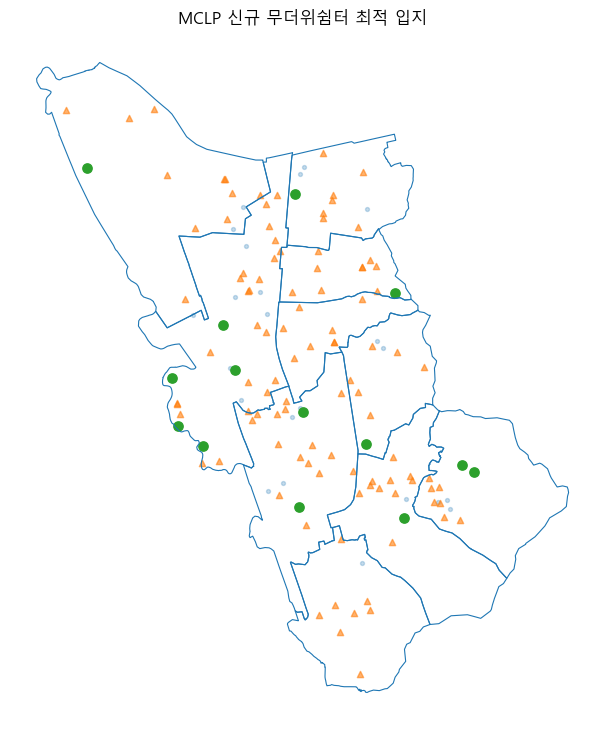

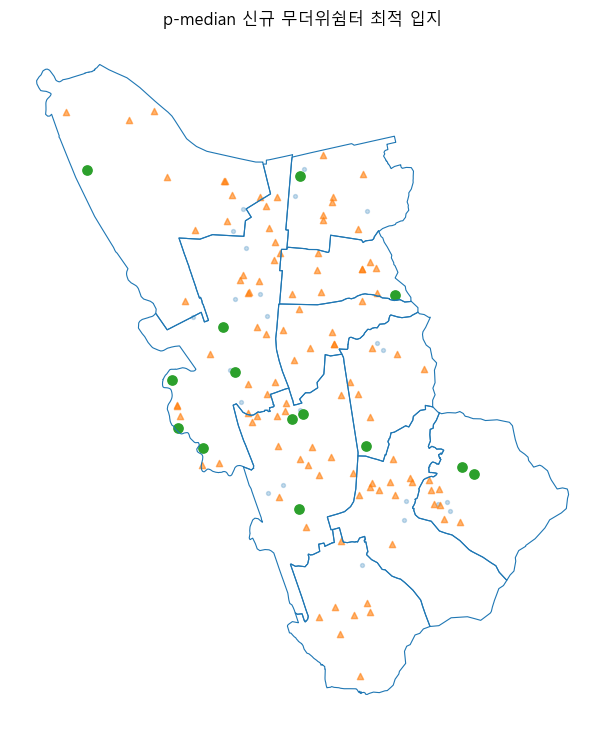

In [30]:
from matplotlib import font_manager

# 추가: Windows 한글 글꼴 설정
font_path = r"C:\Windows\Fonts\malgun.ttf"
font_name = font_manager.FontProperties(fname=font_path).get_name()

plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

fig, ax = plt.subplots(figsize=(9, 9))

adm_dong.boundary.plot(ax=ax, linewidth=0.8)
candidate_clean.plot(ax=ax, markersize=8, alpha=0.25)
existing_clean.plot(ax=ax, marker="^", markersize=20, alpha=0.6)

if len(selected_mclp):
    selected_mclp.plot(ax=ax, marker="o", markersize=45)

ax.set_title("MCLP 신규 무더위쉼터 최적 입지")
ax.set_axis_off()
plt.show()

fig, ax = plt.subplots(figsize=(9, 9))

adm_dong.boundary.plot(ax=ax, linewidth=0.8)
candidate_clean.plot(ax=ax, markersize=8, alpha=0.25)
existing_clean.plot(ax=ax, marker="^", markersize=20, alpha=0.6)

if len(selected_pmedian):
    selected_pmedian.plot(ax=ax, marker="o", markersize=45)

ax.set_title("p-median 신규 무더위쉼터 최적 입지")
ax.set_axis_off()
plt.show()


## 13. 결과 저장

In [31]:
OUTPUT_DIR = BASE_DIR / "output"
OUTPUT_DIR.mkdir(exist_ok=True)

comparison.to_csv(
    OUTPUT_DIR / "model_comparison.csv",
    index=False,
    encoding="utf-8-sig"
)

selected_mclp.to_file(
    OUTPUT_DIR / "selected_mclp.gpkg",
    layer="selected_mclp",
    driver="GPKG"
)

selected_pmedian.to_file(
    OUTPUT_DIR / "selected_pmedian.gpkg",
    layer="selected_pmedian",
    driver="GPKG"
)

selected_mclp.drop(columns="geometry").to_csv(
    OUTPUT_DIR / "selected_mclp.csv",
    index=False,
    encoding="utf-8-sig"
)

selected_pmedian.drop(columns="geometry").to_csv(
    OUTPUT_DIR / "selected_pmedian.csv",
    index=False,
    encoding="utf-8-sig"
)

print("저장 완료:", OUTPUT_DIR)


저장 완료: C:\Users\kwang\OneDrive\바탕 화면\공모전\금천구 더움쉼터 입지 분석 프로젝트\데이터\output


## 14. 선택: MCLP 서비스거리 민감도 분석

최종 `D`가 확정되기 전에는 여러 거리 기준에서 MCLP 선정지가 얼마나 안정적인지 확인할 수 있습니다.


In [ ]:
def run_mclp_for_distance(distance_m, p=P, msg=False):
    coverage_matrix = (
        np.isfinite(demand_candidate_dist)
        & (demand_candidate_dist <= distance_m)
    )

    existing_cov = (
        demand_model["nearest_existing_m"].to_numpy(float)
        <= distance_m
    )

    _, status, selected = solve_mclp(
        weights=weights,
        existing_covered=existing_cov,
        coverage_matrix=coverage_matrix,
        p=p,
        msg=msg
    )

    covered = existing_cov.copy()
    if selected:
        covered |= coverage_matrix[:, selected].any(axis=1)

    return {
        "distance_m": distance_m,
        "status": status,
        "coverage_pct": weighted_coverage(covered, weights) * 100,
        "selected_idx": selected
    }


# 예시
# sensitivity = [
#     run_mclp_for_distance(d)
#     for d in [250, 300, 350]
# ]
#
# pd.DataFrame([
#     {
#         "distance_m": r["distance_m"],
#         "status": r["status"],
#         "coverage_pct": r["coverage_pct"],
#         "n_selected": len(r["selected_idx"])
#     }
#     for r in sensitivity
# ])


: 